# Задание №1

Классические нейросети на Skl, TF, PyT для классификации семян


In [ ]:
# ЛР 3. Классические нейросети на Skl, TF, PyT для классификации семян

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Лаба3/seeds.csv', delimiter=';')
df

MessageError: Error: credential propagation was unsuccessful

Проверка сбалансированности данных по целевому атрибуту

In [ ]:
df['Class (1, 2, 3) (target)'].hist()
plt.title('Распределение классов семян')
plt.show()

Отделяем предикторы и сохраняем их в переменную Х, а целевой атрибут - в переменую Y

In [ ]:
X = df.drop(columns=['Class (1, 2, 3) (target)'])
X
Y = df['Class (1, 2, 3) (target)']
Y

Разделяем выборку на обучающую и тестовую части


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=1, stratify=Y)

# SKLearn

In [ ]:
# Инициализация модели
model = MLPClassifier(hidden_layer_sizes=[50, 30], max_iter=1000, random_state=1)

# Обучение модели
model.fit(x_train, y_train)

# Тестирование модели
test_predictions = model.predict([[14.5, 14.3, 0.87, 5.5, 3.2, 2.8, 5.1],
                                  [18.5, 16.2, 0.88, 6.1, 3.7, 3.5, 6.0]])
print("Тестовые предсказания:", test_predictions)

Вычисление метрик модели:

In [ ]:
# Прогоняем тестовую выборку через модель и сохраняем ответы
y_pred_lr = model.predict(x_test)

y_test

# Для визуального сравнения
comparison_df = pd.DataFrame({'Предсказанные': y_pred_lr, 'Истинные': y_test.values})
comparison_df

,Предсказанные,Истинные
0,1,1
1,3,3
2,2,2
3,2,2
4,3,3
5,2,2
6,1,1
7,2,2
8,2,2
9,3,3




1.   Метрика точности (accuracy);
2.   Матрица ошибок;



Точность Scikit-learn модели: 0.8491
Матрица ошибок:
[[14  1  3]
 [ 0 18  0]
 [ 0  4 13]]


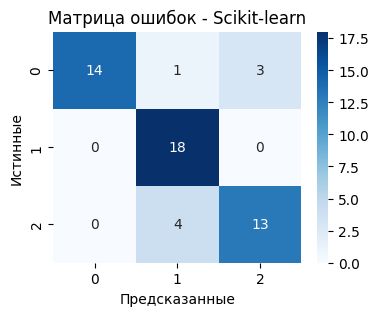

In [ ]:
accuracy_sklearn = accuracy_score(y_test, y_pred_lr)
print(f"Точность Scikit-learn модели: {accuracy_sklearn:.4f}")

cm_sklearn = confusion_matrix(y_test, y_pred_lr)
print("Матрица ошибок:")
print(cm_sklearn)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_sklearn, annot=True, cmap='Blues', ax=ax)
ax.set_xlabel('Предсказанные')
ax.set_ylabel('Истинные')
ax.set_title('Матрица ошибок - Scikit-learn')
plt.show()

Метрики precision, recall, F1 (усредненные):

Precision: 0.8660
Recall: 0.8491
F1-score: 0.8481


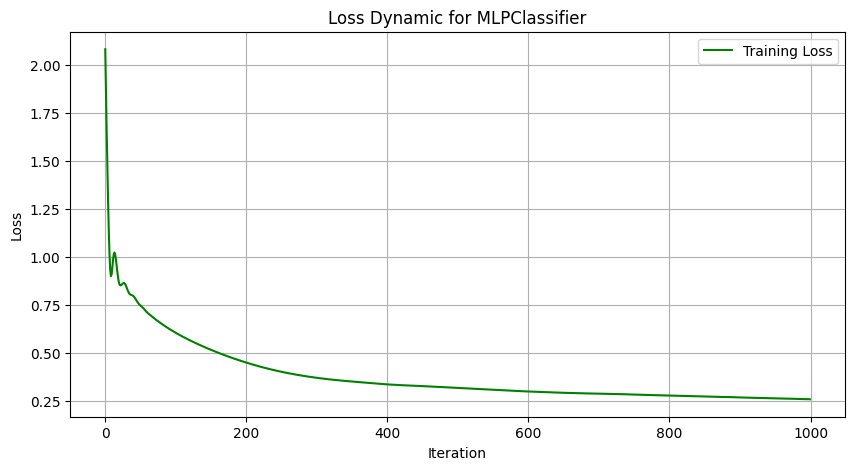

In [ ]:
precision_sklearn = precision_score(y_test, y_pred_lr, average='weighted')
recall_sklearn = recall_score(y_test, y_pred_lr, average='weighted')
f1_sklearn = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Precision: {precision_sklearn:.4f}")
print(f"Recall: {recall_sklearn:.4f}")
print(f"F1-score: {f1_sklearn:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(model.loss_curve_, label='Training Loss', color='green')
plt.title('Loss Dynamic for MLPClassifier')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# TensorFlow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

Преобразуем данные в numpy arrays для TensorFlow (1,2,3 в 0,1,2)

In [ ]:
x_train_tf = x_train.values.astype('float32')
y_train_tf = y_train.values.astype('int32') - 1
x_test_tf = x_test.values.astype('float32')
y_test_tf = y_test.values.astype('int32') - 1

In [ ]:
model_tf = Sequential()
model_tf.add(Input(shape=(7,)))
model_tf.add(Dense(128, activation='relu'))
model_tf.add(Dense(64, activation='relu'))
model_tf.add(Dense(32, activation='softmax'))

model_tf.summary()

NameError: name 'Sequential' is not defined

In [ ]:
model_tf.compile(optimizer=Adam(learning_rate=0.01),
   loss='sparse_categorical_crossentropy',
   metrics=['accuracy'])

history_tf = model_tf.fit(x_train_tf, y_train_tf,
                         validation_data=(x_test_tf, y_test_tf),
                         epochs=100, batch_size=16, verbose=1)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3905 - loss: 1.5478 - val_accuracy: 0.4906 - val_loss: 1.1301
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5114 - loss: 1.0055 - val_accuracy: 0.5660 - val_loss: 0.9323
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5090 - loss: 0.8889 - val_accuracy: 0.6038 - val_loss: 0.8507
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7148 - loss: 0.7500 - val_accuracy: 0.5660 - val_loss: 0.8508
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6475 - loss: 0.6769 - val_accuracy: 0.6415 - val_loss: 0.8478
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6499 - loss: 0.7124 - val_accuracy: 0.6792 - val_loss: 0.8836
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6579 - loss: 0.6996 - val_accuracy: 0.6415 - val_loss: 0.8335
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7562 - loss: 0.6213 - val_accuracy: 0.

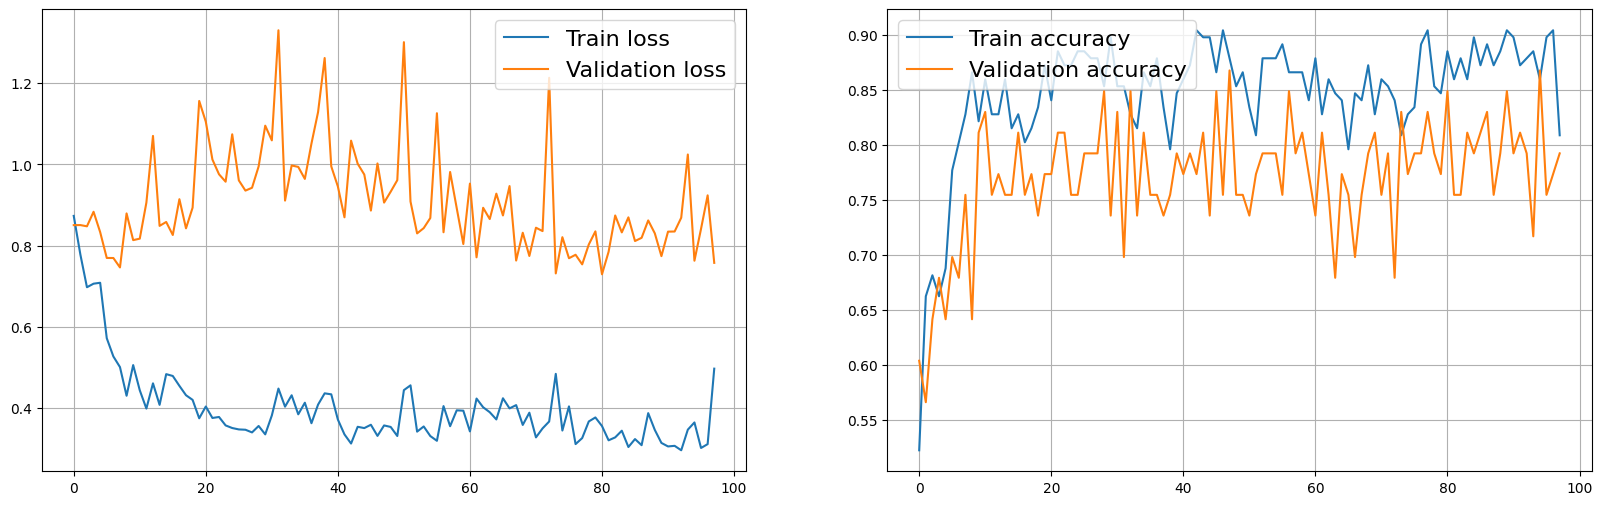

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

axs[0].plot(history_tf.history['loss'][2:], label='Train loss')
axs[0].plot(history_tf.history['val_loss'][2:], label='Validation loss')
axs[0].grid(True)
axs[0].legend(loc=1, prop={'size': 16})

axs[1].plot(history_tf.history['accuracy'][2:], label='Train accuracy')
axs[1].plot(history_tf.history['val_accuracy'][2:], label='Validation accuracy')
axs[1].grid(True)
axs[1].legend(loc=2, prop={'size': 16})

plt.show()

Вычисление метрик модели:

In [ ]:
# Прогоняем тестовую выборку через модель и сохраняем ответы
y_pred_tf = model_tf.predict(x_test_tf)
y_pred_tf_classes = np.argmax(y_pred_tf, axis=1)

# Преобразуем обратно для сравнения с исходными метками
y_pred_tf_classes_original = y_pred_tf_classes + 1
y_test

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


,"Class (1, 2, 3) (target)"
20,1
158,3
86,2
128,2
156,3
94,2
56,1
118,2
81,2
163,3




1.   Метрика точности (accuracy);
2.   Матрица ошибок;



In [ ]:
comparison_tf_df = pd.DataFrame({'Предсказанные': y_pred_tf_classes_original, 'Истинные': y_test.values})
comparison_tf_df

accuracy_tf = accuracy_score(y_test, y_pred_tf_classes_original)
print(f"Точность TensorFlow модели: {accuracy_tf:.4f}")

cm_tf = confusion_matrix(y_test, y_pred_tf_classes_original)
print("Матрица ошибок:")
print(cm_tf)

Точность TensorFlow модели: 0.7925
Матрица ошибок:
[[17  0  1]
 [ 5 13  0]
 [ 3  2 12]]


Метрики precision, recall, F1:

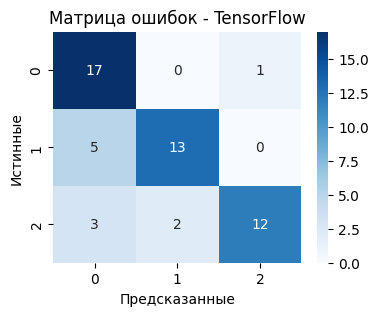

Precision: 0.8214
Recall: 0.7925
F1-score: 0.7927


In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_tf, annot=True, cmap='Blues', ax=ax)
ax.set_xlabel('Предсказанные')
ax.set_ylabel('Истинные')
ax.set_title('Матрица ошибок - TensorFlow')
plt.show()

precision_tf = precision_score(y_test, y_pred_tf_classes_original, average='weighted')
recall_tf = recall_score(y_test, y_pred_tf_classes_original, average='weighted')
f1_tf = f1_score(y_test, y_pred_tf_classes_original, average='weighted')

print(f"Precision: {precision_tf:.4f}")
print(f"Recall: {recall_tf:.4f}")
print(f"F1-score: {f1_tf:.4f}")

# PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

Преобразуем данные в numpy arrays для TensorFlow (1,2,3 в 0,1,2)

In [ ]:
x_train_pt = torch.FloatTensor(x_train.values)
y_train_pt = torch.LongTensor(y_train.values - 1)
x_test_pt = torch.FloatTensor(x_test.values)
y_test_pt = torch.LongTensor(y_test.values - 1)

In [ ]:
# Create DataLoader for batching
train_data = TensorDataset(x_train_pt, y_train_pt)
test_data = TensorDataset(x_test_pt, y_test_pt)
train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
test_loader = DataLoader(test_data, batch_size=8)

# Определяем архитектуру нейронной сети с использованием nn.Sequential
model_pt = nn.Sequential(
    nn.Linear(7, 50),   # Входной слой (7 признаков) -> Первый скрытый слой (50 нейронов)
    nn.ReLU(),          # Функция активации ReLU
    nn.Linear(50, 30),  # Первый скрытый слой (50 нейронов) -> Второй скрытый слой (30 нейронов)
    nn.ReLU(),          # Функция активации ReLU
    nn.Linear(30, 3)    # Второй скрытый слой (30 нейронов) -> Выходной слой (3 класса)
)

# Перемещаем модель на GPU, если он доступен
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")
model_pt.to(device)

Используется устройство: cpu


Sequential(
  (0): Linear(in_features=7, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=30, bias=True)
  (3): ReLU()
  (4): Linear(in_features=30, out_features=3, bias=True)
)

In [ ]:
# Определяем алгоритм оптимизации и функцию потерь
optimizer = optim.AdamW(model_pt.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()


In [ ]:
# Функция для проведения одной эпохи обучения
def train_one_epoch(model, epoch, train_data_loader, test_data_loader, optimizer, criterion, device):
    model.train()   # переводим модель в режим обучения
    total_loss, correct, test_total_loss, test_correct = 0, 0, 0, 0
    progress_bar = tqdm(train_data_loader, desc=f"Epoch {epoch}", leave=False)
    for images, labels in progress_bar:  # перебор обучающей выборки на одной эпохе
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()   # обнуление градиентов
        outputs = model(images) # пропускаем данные батча через модель
        loss = criterion(outputs, labels)   # вычисляем функцию потерь
        loss.backward() # обратное распространение ошибки
        optimizer.step()    # делаем шаг оптимизатора

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

        progress_bar.set_postfix_str(f"Loss: {total_loss / len(train_data_loader):.4f}, Accuracy: {correct / len(train_data_loader.dataset):.4f}")

    # Подсчет метрик на тестовой выборке после окончания эпохи
    model.eval() # переводим модель в режим инференса
    with torch.no_grad():
        for images, labels in test_data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_total_loss += loss.item()
            test_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = total_loss / len(train_data_loader)
    train_accuracy = correct / len(train_data_loader.dataset)
    test_loss = test_total_loss / len(test_data_loader)
    test_accuracy = test_correct / len(test_data_loader.dataset)
    return train_loss, train_accuracy, test_loss, test_accuracy

In [ ]:
epochs = 100
history_pt = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(epochs):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model_pt, epoch, train_loader, test_loader, optimizer, criterion, device)
    history_pt["loss"].append(train_loss)
    history_pt["val_loss"].append(val_loss)
    history_pt["accuracy"].append(accuracy)
    history_pt["val_accuracy"].append(val_accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")

Epoch 1/100, Loss: 0.3295, Accuracy: 0.8662, Test Loss: 0.7836, Test Accuracy: 0.7736


Epoch 2/100, Loss: 0.2958, Accuracy: 0.8981, Test Loss: 0.8214, Test Accuracy: 0.7736


Epoch 3/100, Loss: 0.3170, Accuracy: 0.8917, Test Loss: 0.8141, Test Accuracy: 0.7925


Epoch 4/100, Loss: 0.3227, Accuracy: 0.8854, Test Loss: 0.9001, Test Accuracy: 0.7547


Epoch 5/100, Loss: 0.3693, Accuracy: 0.8408, Test Loss: 0.8033, Test Accuracy: 0.8113


...

Epoch 96/100, Loss: 0.2948, Accuracy: 0.8917, Test Loss: 0.8395, Test Accuracy: 0.7736


Epoch 97/100, Loss: 0.2995, Accuracy: 0.8854, Test Loss: 0.9469, Test Accuracy: 0.7925


Epoch 98/100, Loss: 0.3295, Accuracy: 0.8662, Test Loss: 0.7265, Test Accuracy: 0.8302


Epoch 99/100, Loss: 0.3643, Accuracy: 0.8344, Test Loss: 0.9405, Test Accuracy: 0.7736


Epoch 100/100, Loss: 0.2883, Accuracy: 0.8917, Test Loss: 1.0734, Test Accuracy: 0.7925


In [ ]:
model_pt.eval()
# Прогоняем тестовую выборку через модель и сохраняем ответы
with torch.no_grad():
    y_pred_pt = model_pt(x_test_pt.to(device))

y_pred_softmax = torch.softmax(y_pred_pt, dim=1)
y_pred_pt_classes = torch.argmax(y_pred_softmax, dim=1).cpu()

# Преобразуем обратно к исходным меткам (1,2,3) для сравнения
y_pred_pt_classes_original = y_pred_pt_classes + 1
y_test_original = y_test_pt + 1

print("Предсказания PyTorch (исходные метки):", y_pred_pt_classes_original[:10].numpy())
print("Истинные метки (исходные):", y_test_original[:10].numpy())

# Для визуального сравнения
comparison_pt_df = pd.DataFrame({'Предсказанные': y_pred_pt_classes_original.numpy(), 'Истинные': y_test_original.numpy()})
print("\nСравнение предсказаний:")
print(comparison_pt_df.head(10))

Предсказания PyTorch (исходные метки): [3 3 2 2 3 2 1 2 2 3]
Истинные метки (исходные): [1 3 2 2 3 2 1 2 2 3]

Сравнение предсказаний:
   Предсказанные  Истинные
0              3         1
1              3         3
2              2         2
3              2         2
4              3         3
5              2         2
6              1         1
7              2         2
8              2         2
9              3         3


Вычисление метрик модели:



1.   Метрика точности (accuracy);
2.   Матрица ошибок;



Точность PyTorch модели: 0.7925
Матрица ошибок:
[[13  0  5]
 [ 2 16  0]
 [ 0  4 13]]


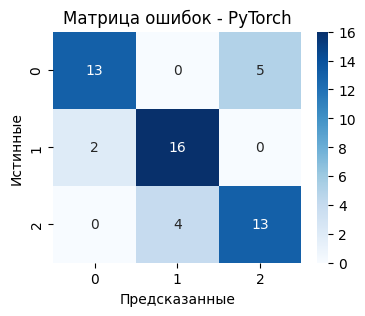

Precision: 0.7977
Recall: 0.7925
F1-score: 0.7919


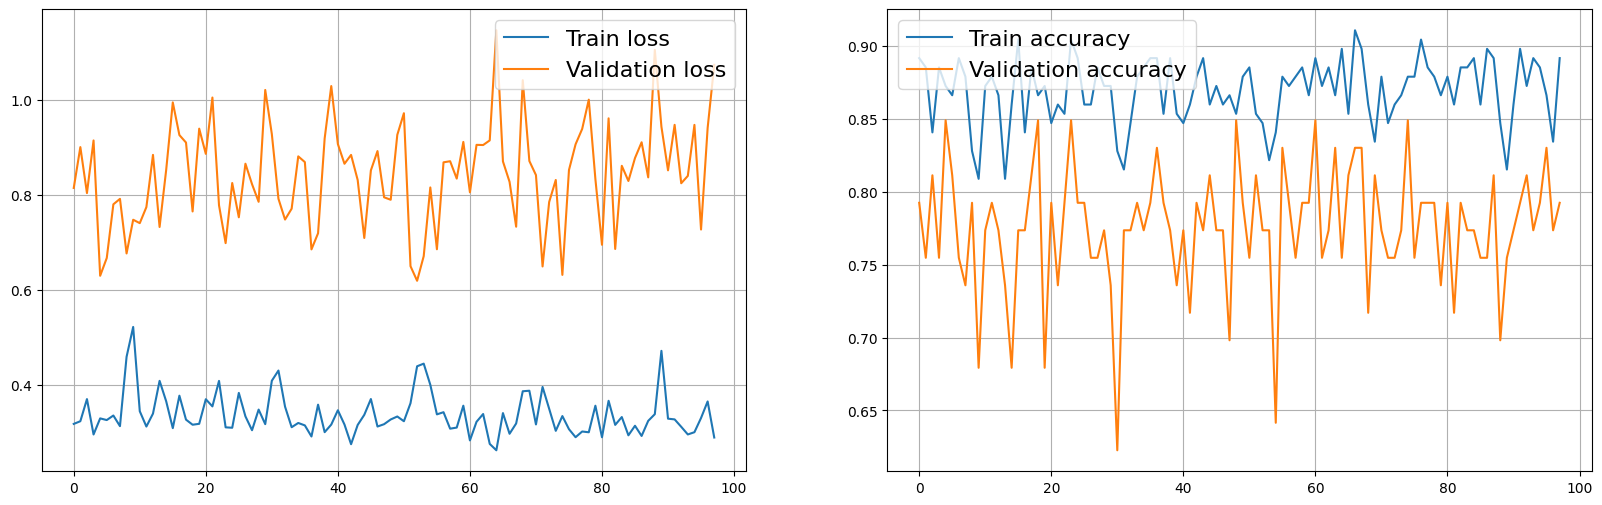

In [ ]:
accuracy_pt = accuracy_score(y_test_original, y_pred_pt_classes_original)
print(f"Точность PyTorch модели: {accuracy_pt:.4f}")

cm_pt = confusion_matrix(y_test_original, y_pred_pt_classes_original)
print("Матрица ошибок:")
print(cm_pt)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_pt, annot=True, cmap='Blues', ax=ax)
ax.set_xlabel('Предсказанные')
ax.set_ylabel('Истинные')
ax.set_title('Матрица ошибок - PyTorch')
plt.show()

precision_pt = precision_score(y_test_original, y_pred_pt_classes_original, average='weighted')
recall_pt = recall_score(y_test_original, y_pred_pt_classes_original, average='weighted')
f1_pt = f1_score(y_test_original, y_pred_pt_classes_original, average='weighted')

print(f"Precision: {precision_pt:.4f}")
print(f"Recall: {recall_pt:.4f}")
print(f"F1-score: {f1_pt:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(20, 6))

axs[0].plot(history_pt['loss'][2:], label='Train loss')
axs[0].plot(history_pt['val_loss'][2:], label='Validation loss')
axs[0].grid(True)
axs[0].legend(loc=1, prop={'size': 16})

axs[1].plot(history_pt['accuracy'][2:], label='Train accuracy')
axs[1].plot(history_pt['val_accuracy'][2:], label='Validation accuracy')
axs[1].grid(True)
axs[1].legend(loc=2, prop={'size': 16})

plt.show()

# Задание №2

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размеры данных:
Обучающая выборка: (60000, 28, 28)
Тестовая выборка: (10000, 28, 28)
Метки обучения: (60000,)
Метки теста: (10000,)


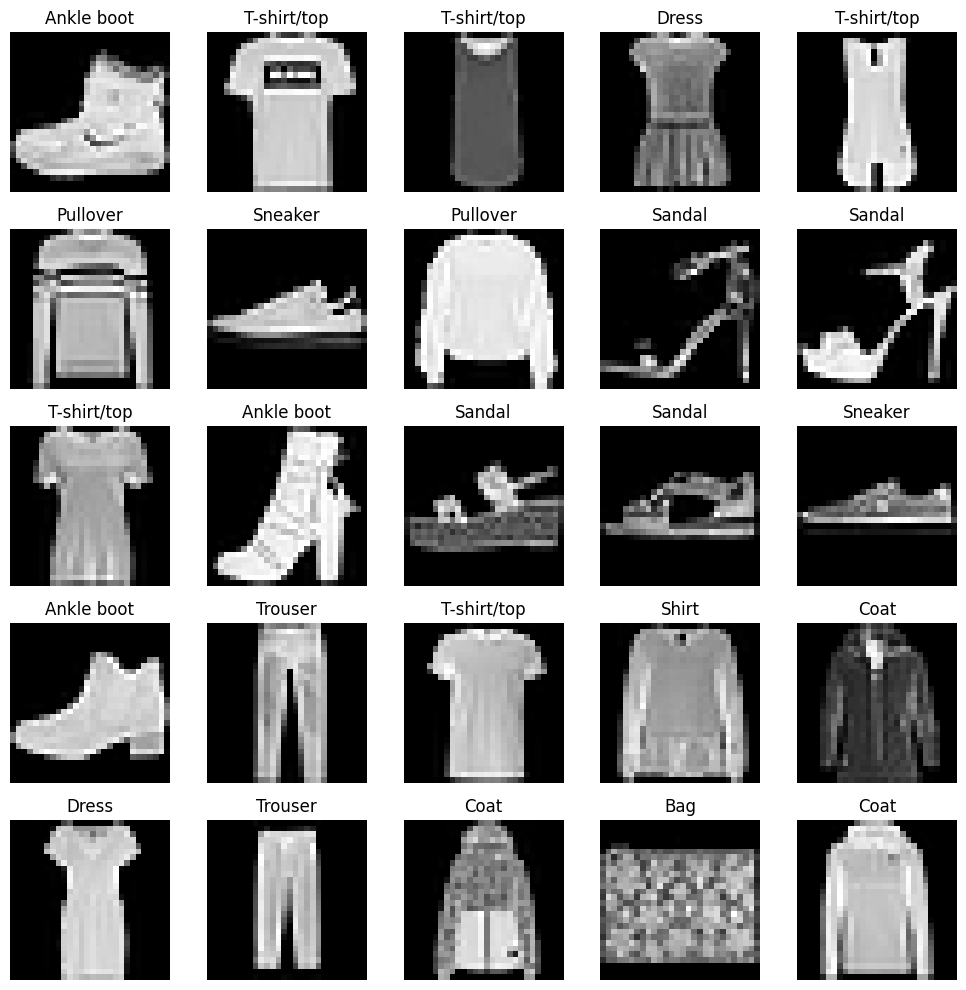

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,890 (2.21 MB)

 Trainable params: 576,970 (2.20 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.7022 - loss: 0.8778 - val_accuracy: 0.8292 - val_loss: 0.4797 - learning_rate: 0.0010
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8383 - loss: 0.4532 - val_accuracy: 0.8479 - val_loss: 0.4282 - learning_rate: 0.0010
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.8515 - loss: 0.4126 - val_accuracy: 0.8505 - val_loss: 0.4289 - learning_rate: 0.0010
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8613 - loss: 0.3871 - val_accuracy: 0.8513 - val_loss: 0.4180 - learning_rate: 0.0010
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8636 - loss: 0.3766 - val_accuracy: 0.8577 - val_loss: 0.4084 - learning_rate: 0.0010
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8677 - loss: 0.3619 - val_accuracy: 0.8558 - val_loss: 0.4003 - learning_rate: 0.0010
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8740 - 

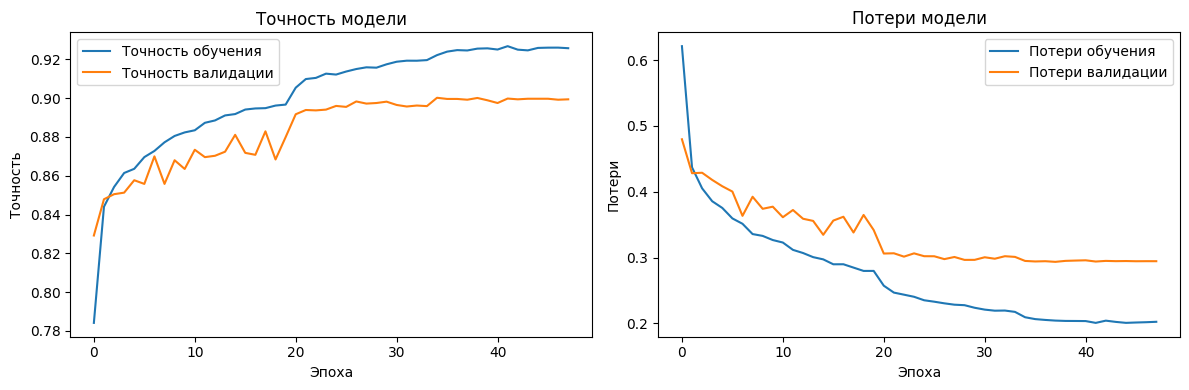

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Подробный отчет по классификации:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.84      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.82      0.81      0.82      1000
       Dress       0.90      0.91      0.90      1000
        Coat       0.81      0.84      0.83      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.72      0.72      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



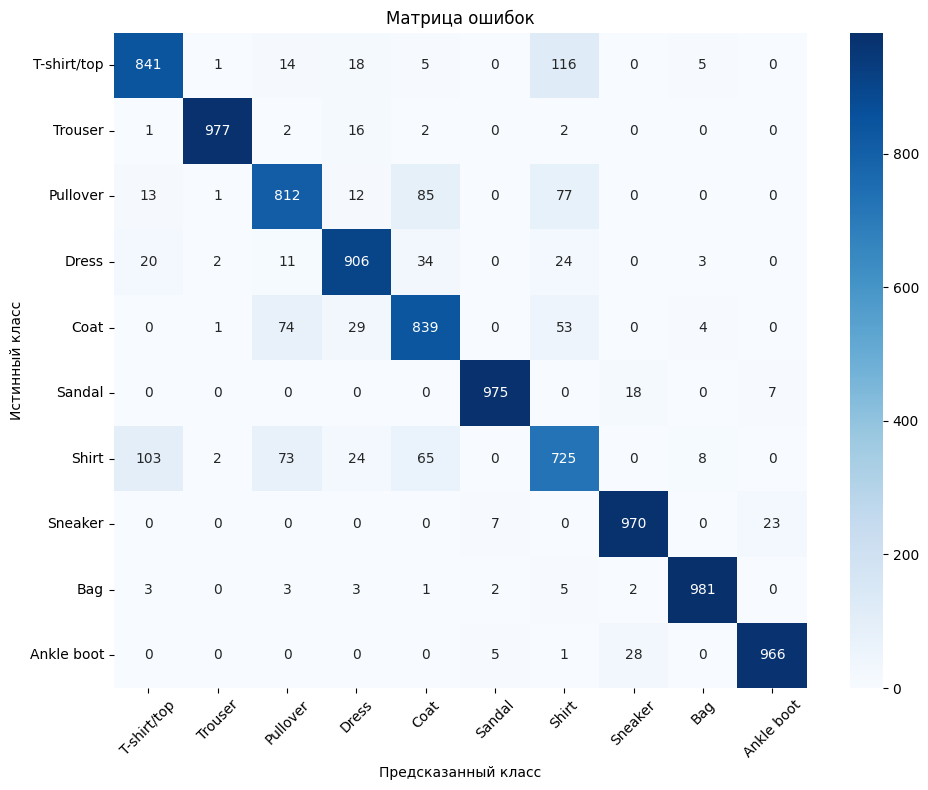

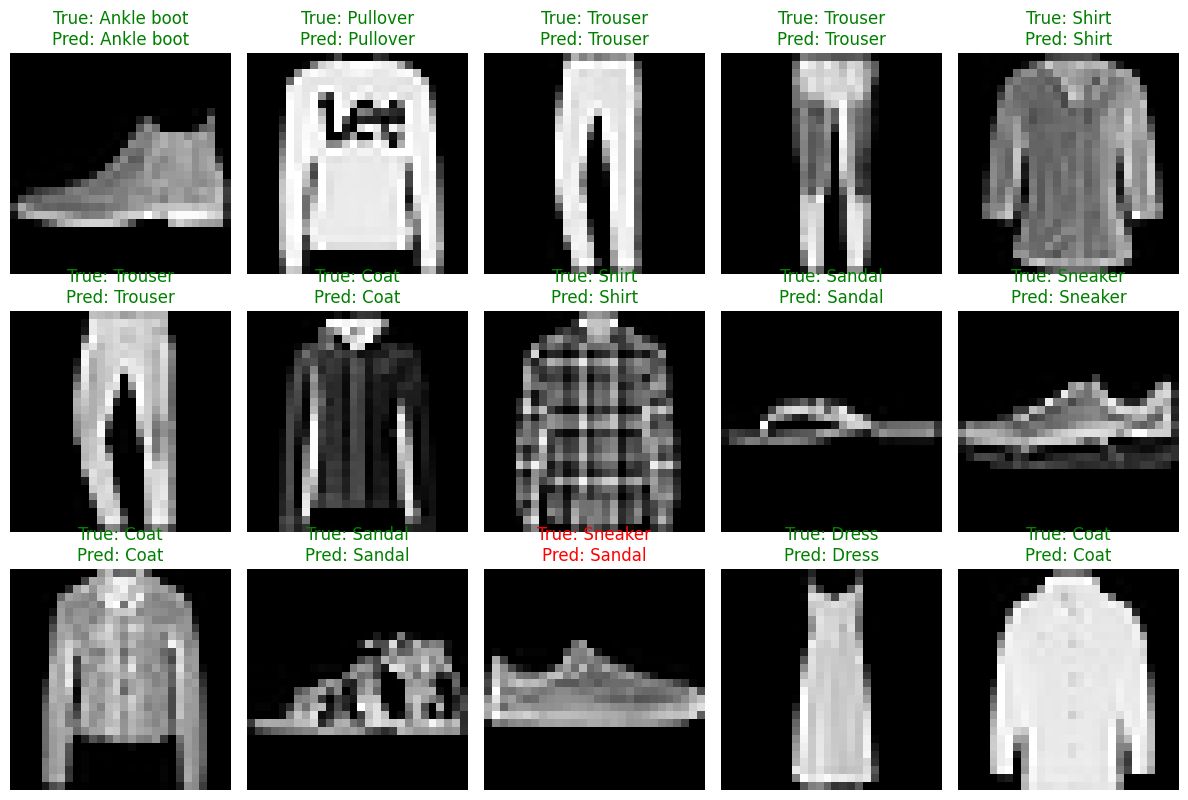


Анализ точности по классам:
T-shirt/top: 0.8410
Trouser: 0.9770
Pullover: 0.8120
Dress: 0.9060
Coat: 0.8390
Sandal: 0.9750
Shirt: 0.7250
Sneaker: 0.9700
Bag: 0.9810
Ankle boot: 0.9660


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Загрузка данных Fashion MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Размеры данных:")
print(f"Обучающая выборка: {x_train.shape}")
print(f"Тестовая выборка: {x_test.shape}")
print(f"Метки обучения: {y_train.shape}")
print(f"Метки теста: {y_test.shape}")

# Предварительная обработка данных
# Нормализация пикселей к диапазону [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Преобразование меток в one-hot encoding
y_train_categorical = keras.utils.to_categorical(y_train, 10)
y_test_categorical = keras.utils.to_categorical(y_test, 10)

# Изменение формы данных
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

# Визуализация нескольких примеров
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Построение модели
def create_model():
    model = keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(10, activation='softmax')
    ])

    return model

# Создание и компиляция модели
model = create_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Вывод архитектуры модели
model.summary()

# Коллбеки для улучшения обучения
callbacks = [
    keras.callbacks.EarlyStopping(
        # Останавливает обучение, если потери не уменьшаются на протяжении 10 эпох
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        # Уменьшает learning rate, если потери не уменьшаются на протяжении 5 эпох
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7
    )
]

# Обучение модели
history = model.fit(
    x_train_flat, y_train_categorical,
    batch_size=256,
    epochs=100,
    validation_data=(x_test_flat, y_test_categorical),
    callbacks=callbacks,
    verbose=1
)

# Оценка модели на тестовых данных
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test_categorical, verbose=0)
print(f"\nТочность на тестовых данных: {test_accuracy:.4f}")
print(f"Потери на тестовых данных: {test_loss:.4f}")

# Графики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность обучения')
plt.plot(history.history['val_accuracy'], label='Точность валидации')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Потери обучения')
plt.plot(history.history['val_loss'], label='Потери валидации')
plt.title('Потери модели')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()

# Предсказания на тестовых данных
y_pred = model.predict(x_test_flat)
y_pred_classes = np.argmax(y_pred, axis=1)

# Подробный отчет по классификации
print("\nПодробный отчет по классификации:")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Матрица ошибок
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Визуализация нескольких предсказаний
plt.figure(figsize=(12, 8))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')

    true_label = class_names[y_test[i]]
    pred_label = class_names[y_pred_classes[i]]

    color = 'green' if y_test[i] == y_pred_classes[i] else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Анализ наиболее проблемных классов
print("\nАнализ точности по классам:")
class_accuracy = {}
for i in range(10):
    mask = y_test == i
    accuracy = (y_pred_classes[mask] == i).mean()
    class_accuracy[class_names[i]] = accuracy
    print(f"{class_names[i]}: {accuracy:.4f}")


